In [1]:
!pip install pandas schedule python-dotenv

In [2]:
import os

folders = [
    "data",
    "templates",
    "outputs",
    "logs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [3]:
import pandas as pd

contacts = pd.DataFrame({
    "name": ["Rahul", "Priya", "Amit"],
    "email": [
        "rahul@example.com",
        "priya@example.com",
        "amit@example.com"
    ]
})

contacts.to_csv("data/contacts.csv", index=False)

print("contacts.csv created")

contacts.csv created


In [4]:
reminders = pd.DataFrame({
    "email": [
        "rahul@example.com",
        "priya@example.com",
        "amit@example.com"
    ],
    "subject": [
        "Meeting Reminder",
        "Assignment Reminder",
        "Payment Reminder"
    ]
})

reminders.to_csv("data/reminders.csv", index=False)

print("reminders.csv created")

reminders.csv created


In [5]:
template = """
Hello {name},

This is your automated reminder.

Please complete your pending task.

Thank You,
Automation Team
"""

with open("templates/reminder_template.txt", "w") as file:
    file.write(template)

print("Template created")

Template created


In [6]:
import pandas as pd
import logging
from datetime import datetime

# DRY RUN MODE
DRY_RUN = True

# Logging setup
logging.basicConfig(
    filename='logs/app.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Read files
contacts_df = pd.read_csv("data/contacts.csv")
reminders_df = pd.read_csv("data/reminders.csv")

# Load template
with open("templates/reminder_template.txt", "r") as file:
    template = file.read()


def send_email(to_email, subject, message):

    if DRY_RUN:
        print(f"[DRY RUN] Email sent to {to_email}")
        logging.info(f"DRY RUN email sent to {to_email}")
        return "SUCCESS"

    return "FAILED"


report_data = []

for _, reminder in reminders_df.iterrows():

    contact = contacts_df[
        contacts_df["email"] == reminder["email"]
    ]

    if contact.empty:
        continue

    name = contact.iloc[0]["name"]

    personalized_message = template.replace("{name}", name)

    status = send_email(
        reminder["email"],
        reminder["subject"],
        personalized_message
    )

    report_data.append({
        "name": name,
        "email": reminder["email"],
        "subject": reminder["subject"],
        "status": status,
        "timestamp": datetime.now()
    })

report_df = pd.DataFrame(report_data)

report_df.to_csv(
    "outputs/email_report.csv",
    index=False
)

print("\nReport generated successfully")

[DRY RUN] Email sent to rahul@example.com
[DRY RUN] Email sent to priya@example.com
[DRY RUN] Email sent to amit@example.com

Report generated successfully


In [8]:
print("Hello")

Hello


In [9]:
report_df = pd.read_csv("outputs/email_report.csv")

report_df

,name,email,subject,status,timestamp
0,Rahul,rahul@example.com,Meeting Reminder,SUCCESS,2026-05-17 13:07:30.375587
1,Priya,priya@example.com,Assignment Reminder,SUCCESS,2026-05-17 13:07:30.377063
2,Amit,amit@example.com,Payment Reminder,SUCCESS,2026-05-17 13:07:30.378055


In [10]:
from google.colab import files

files.download("outputs/email_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

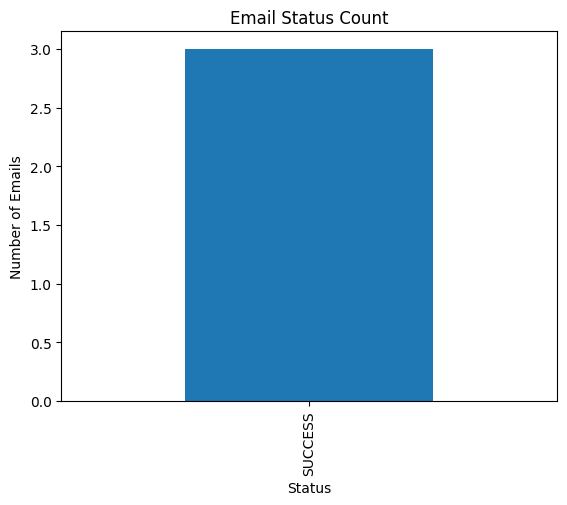

In [14]:
import matplotlib.pyplot as plt

status_counts = report_df["status"].value_counts()

status_counts.plot(kind="bar")

plt.title("Email Status Count")
plt.xlabel("Status")
plt.ylabel("Number of Emails")

plt.show()

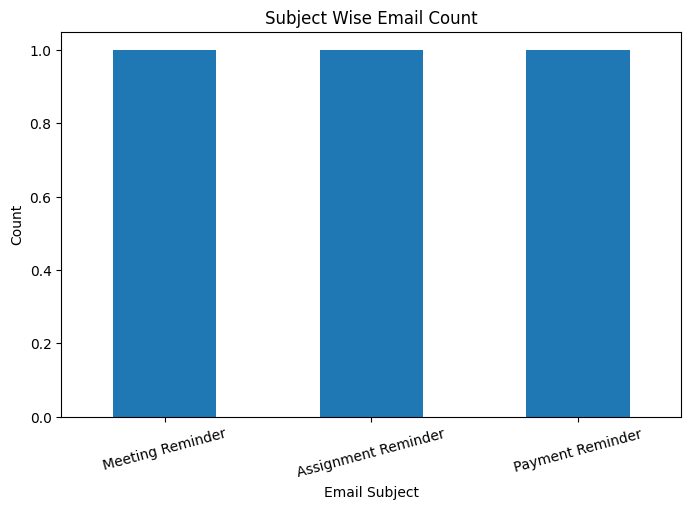

In [15]:
subject_counts = report_df["subject"].value_counts()

plt.figure(figsize=(8,5))

subject_counts.plot(kind="bar")

plt.title("Subject Wise Email Count")
plt.xlabel("Email Subject")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

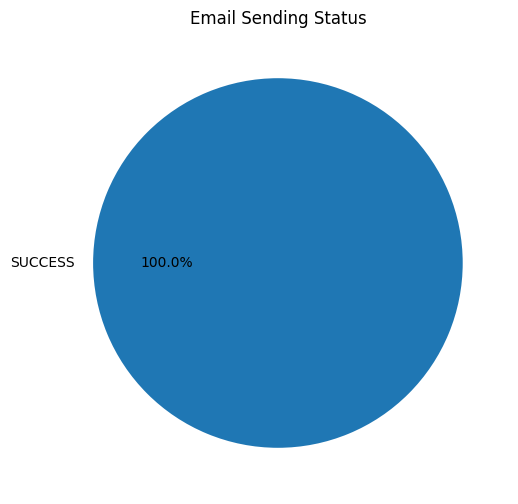

In [16]:
status_counts = report_df["status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title("Email Sending Status")

plt.show()

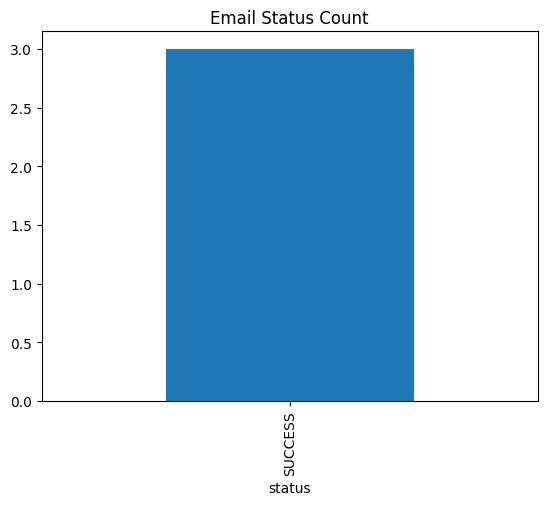

In [17]:
status_counts.plot(kind="bar")

plt.title("Email Status Count")

plt.savefig("email_status_graph.png")

plt.show()

In [18]:
from google.colab import files

files.download("email_status_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>